# Circadian Rhythm
Kailin Liu, Melody Yazdi, Richard Zhang

In [3]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

# Base Model

In [5]:
# Circadian oscillator parameters
mu = 0.23        # nonlinearity
beta = 0.0075    # light sensitivity 0.0075
pi = 2 * np.pi / 24  # circadian frequency (radians/hour)

# Melatonin PK parameters
ka = 1.0         # absorption rate (1/hr)
ke = 0.3         # elimination rate (1/hr)

# PD parameters
Emax = 1.0      # max melatonin effect on oscillator (like light input); set 0.01
EC50 = 1.0       # half-max concentration (arbitrary units)

# Light schedule
def light_input(t):
    # Light on from 6am to 10pm (zeitgeber time 6 to 22)
    t_mod = t % 24
    return 1000.0 if 6 <= t_mod < 22 else 0.0

def dose_function(t, dose_times, dose_amount=1.0):
    return sum(dose_amount for t_dose in dose_times if np.isclose(t, t_dose, atol=0.1))

def circadian_melatonin_model(t, y, dose_times, light_function, dose=1.0, mu=0.23, beta=0.0075,ka=1.0,ke=0.3,Emax=0.01,EC50 = 1.0):
    G, M, x, y_osc = y
    D = dose_function(t, dose_times, dose)
    L_light = light_function(t)
    L_mel = Emax * M / (EC50 + M)
    L_total = L_light + L_mel
    dGdt = D - ka * G
    dMdt = ka * G - ke * M
    dxdt = pi * (y_osc + mu * (x - (4/3)*x**3))
    dydt = pi * (-x + beta * L_total * (1 - x**2) * y_osc)

    return [dGdt, dMdt, dxdt, dydt]

def light_input_dark(t):
    return 0.0

def kronauer_model(t, y, light_function, mu=0.23, beta=0.0075):
    x, y_osc = y
    L_light = light_function(t)
    L_total = L_light
    dxdt = pi * (y_osc + mu * (x - (4/3)*x**3))
    dydt = pi * (-x + beta * L_total * (1 - x**2) * y_osc)
    return [dxdt, dydt]

def kronauer_model_dark(t, y):
    x, y_osc = y
    L_lightd = light_input_dark(t)
    L_total = L_lightd

    dxdt = pi * (y_osc + mu * (x - (4/3)*x**3))
    dydt = pi * (-x + beta * L_total * (1 - x**2) * y_osc)

    return [dxdt, dydt]

# Investigating Different Solvers: RK45 and Radau
No visible difference was observed between the two solvers on the Kronauer model (no melatonin intervention), but a difference was observed on a small dosage, shown below.

Text(0.5, 0.98, 'RK45 Error Propagation Causes Illusory Behavior')

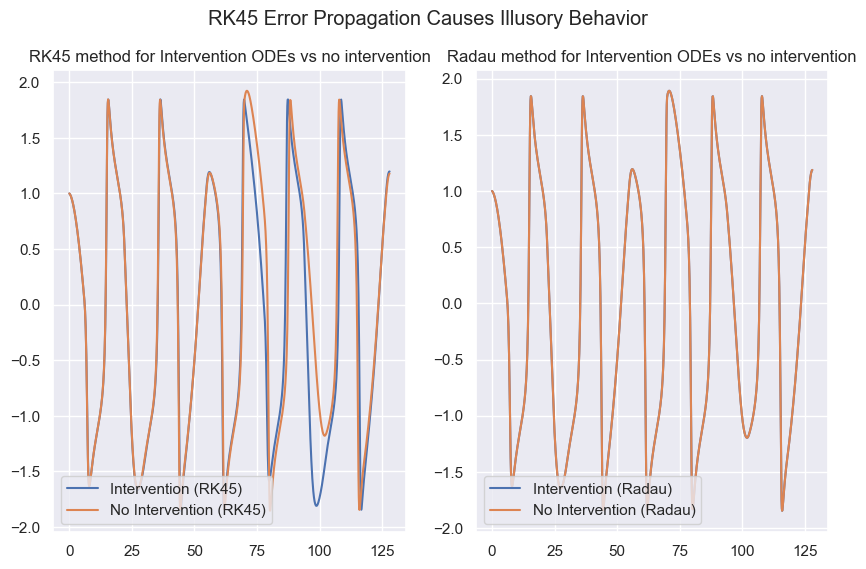

In [7]:
y0 = [0.0, 0.0, 1.0, 0.0]  # Start on limit cycle
dose_times = [20]
t_span = (0, 128)
t_eval = np.linspace(*t_span, 1000)
# Radau
sol = solve_ivp(circadian_melatonin_model, t_span, y0,
                args=(dose_times,light_input,), t_eval=t_eval, method='Radau',atol=1e-10, rtol=1e-5)
# RK45
solrk = solve_ivp(circadian_melatonin_model, t_span, y0,
                args=(dose_times,light_input,), t_eval=t_eval, method='RK45')
# compare with kronauer model (no melatonin dosage)
y0k = [1.0,0.0]
solk = solve_ivp(kronauer_model, t_span, y0k,
                args=(light_input,), t_eval=t_eval, method='Radau',atol=1e-10, rtol=1e-5)
solkrk = solve_ivp(kronauer_model, t_span, y0k,
                args=(light_input,), t_eval=t_eval, method='RK45')
t = sol.t
G, M, x, y_osc = sol.y #Radau
G, M, xrk, yrk_osc = solrk.y #Runge-Kutta
xk, yk_osc = solk.y #Kronauer
xkrk, ykrk_osc = solkrk.y #Kronauer
plt.figure(figsize=(10, 6))
plt.subplot(1, 2, 1)
#plt.plot(t, x, label='Intervention (Radau)')
#plt.plot(t, y_osc, label='Coupled Oscillator (intervention)')
plt.plot(t, xrk, label='Intervention (RK45)')
#plt.plot(t, yk_osc, label='Coupled Oscillator')
plt.plot(t, xkrk, label='No Intervention (RK45)')
plt.title('RK45 method for Intervention ODEs vs no intervention')
plt.legend(loc='lower left')

plt.subplot(1, 2, 2)
plt.plot(t, x, label='Intervention (Radau)')
#plt.plot(t, y_osc, label='Coupled Oscillator (intervention)')
#plt.plot(t, xrk, label='Intervention (RK45)')
#plt.plot(t, yk_osc, label='Coupled Oscillator')
plt.plot(t, xk, label='No Intervention (Radau)')
plt.title('Radau method for Intervention ODEs vs no intervention')
plt.legend(loc='lower left')
plt.suptitle('RK45 Error Propagation Causes Illusory Behavior')

# Creating a Phase Shift
When we used the RK45 solver, the shift in phase due to intervention appeared to happen much later than the dose. However, this was due to numerical error. Thus, we experimented with changing parameters to explore phase-shifting behavior, with and without external light.

Text(0.5, 0.98, 'Melatonin Phase Shift with and without Light')

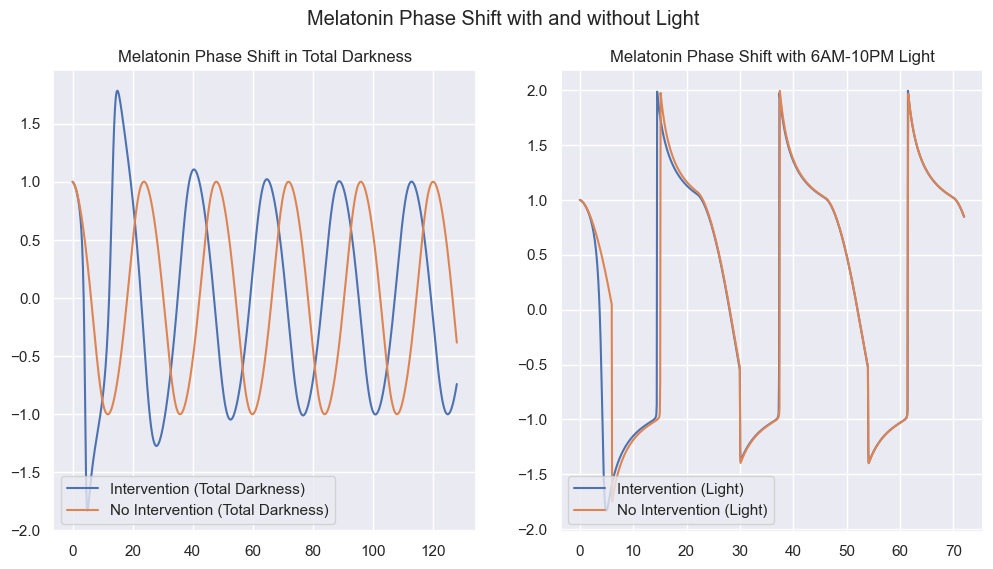

In [9]:
y0 = [0.0, 0.0, 1.0, 0.0]  # Start on limit cycle
dose_times_dark = [0]
dose_times_light = [0]
t_span = (0, 128)
t_eval = np.linspace(*t_span, 1000)
sol_dark = solve_ivp(circadian_melatonin_model, t_span, y0,
                args=(dose_times_dark,light_input_dark,100.0,0.23,0.75,1.0,0.3,10.0,), t_eval=t_eval, method='Radau',atol=1e-10, rtol=1e-5)
y0k = [1.0,0.0]
solk_dark = solve_ivp(kronauer_model, t_span, y0k,
                args=(light_input_dark,0.23,0.75,), t_eval=t_eval, method='Radau',atol=1e-10, rtol=1e-5)
t_spanl = (0, 72) #shorter timespan plotted for light 
t_evall = np.linspace(*t_spanl, 1000)

sol_light = solve_ivp(circadian_melatonin_model, t_spanl, y0,
                args=(dose_times_light,light_input,100.0,0.23,0.75,1.0,0.3,10.0,), t_eval=t_evall, method='Radau',atol=1e-10, rtol=1e-5)

# compare with kronauer model (no melatonin dosage)
y0k = [1.0,0.0]
solk_light = solve_ivp(kronauer_model, t_spanl, y0k,
                args=(light_input,0.23,0.75,), t_eval=t_evall, method='Radau',atol=1e-10, rtol=1e-5)

t = sol_dark.t
tl = sol_light.t
G, M, xd, yd_osc = sol_dark.y 
xkd, ykd_osc = solk_dark.y #Kronauer in dark

G, M, xl, yl_osc = sol_light.y 
xkl, ykl_osc = solk_light.y #Kronauer in light
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(t, xd, label='Intervention (Total Darkness)')
plt.plot(t, xkd, label='No Intervention (Total Darkness)')
plt.title('Melatonin Phase Shift in Total Darkness')
plt.legend(loc='lower left')

plt.subplot(1, 2, 2)
plt.plot(tl, xl, label='Intervention (Light)')
#plt.plot(t, y_osc, label='Coupled Oscillator (intervention)')
#plt.plot(t, xrk, label='Intervention (RK45)')
#plt.plot(t, yk_osc, label='Coupled Oscillator')
plt.plot(tl, xkl, label='No Intervention (Light)')
plt.title('Melatonin Phase Shift with 6AM-10PM Light')
plt.legend(loc='lower left')
plt.suptitle('Melatonin Phase Shift with and without Light')

# Reducing the Elimination Rate
This attempts to model when the oscillator when the rate of melatonin elimination is reduced by a factor of 10, simulating more sensitive individuals

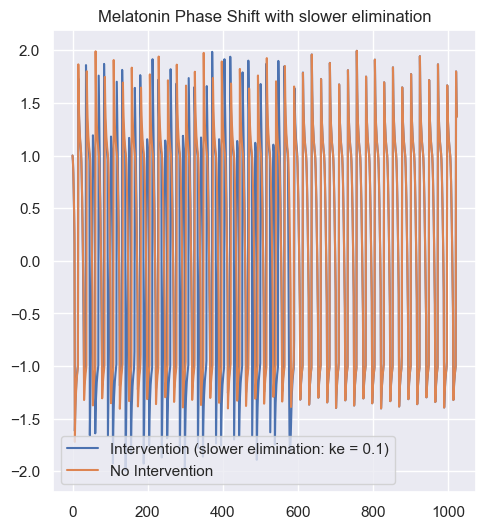

In [36]:
y0 = [0.0, 0.0, 1.0, 0.0]  # Start on limit cycle
dose_times = [0]
t_span = (0, 1024)
t_eval = np.linspace(*t_span, 1000)
sol = solve_ivp(circadian_melatonin_model, t_span, y0,
                args=(dose_times,light_input,100.0,0.23,0.75,1.0,0.1,1.0,), t_eval=t_eval, method='Radau',atol=1e-10, rtol=1e-5)
y0k = [1.0,0.0]
solk = solve_ivp(kronauer_model, t_span, y0k,
                args=(light_input,0.23,0.75,), t_eval=t_eval, method='Radau',atol=1e-10, rtol=1e-5)
t = sol.t
G, M, x, y = sol.y 
xk, yk = solk.y 

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(t, x, label='Intervention (slower elimination: ke = 0.1)')
plt.plot(t, xk, label='No Intervention')
plt.title('Melatonin Phase Shift with slower elimination')
plt.legend(loc='lower left')

# Exploring Bifurcations
We explored possible bifurcations and found a point around mu=28, above which the oscillations approach a steady state

Text(0.5, 0.98, 'Effects of nonlinear term mu on cycle')

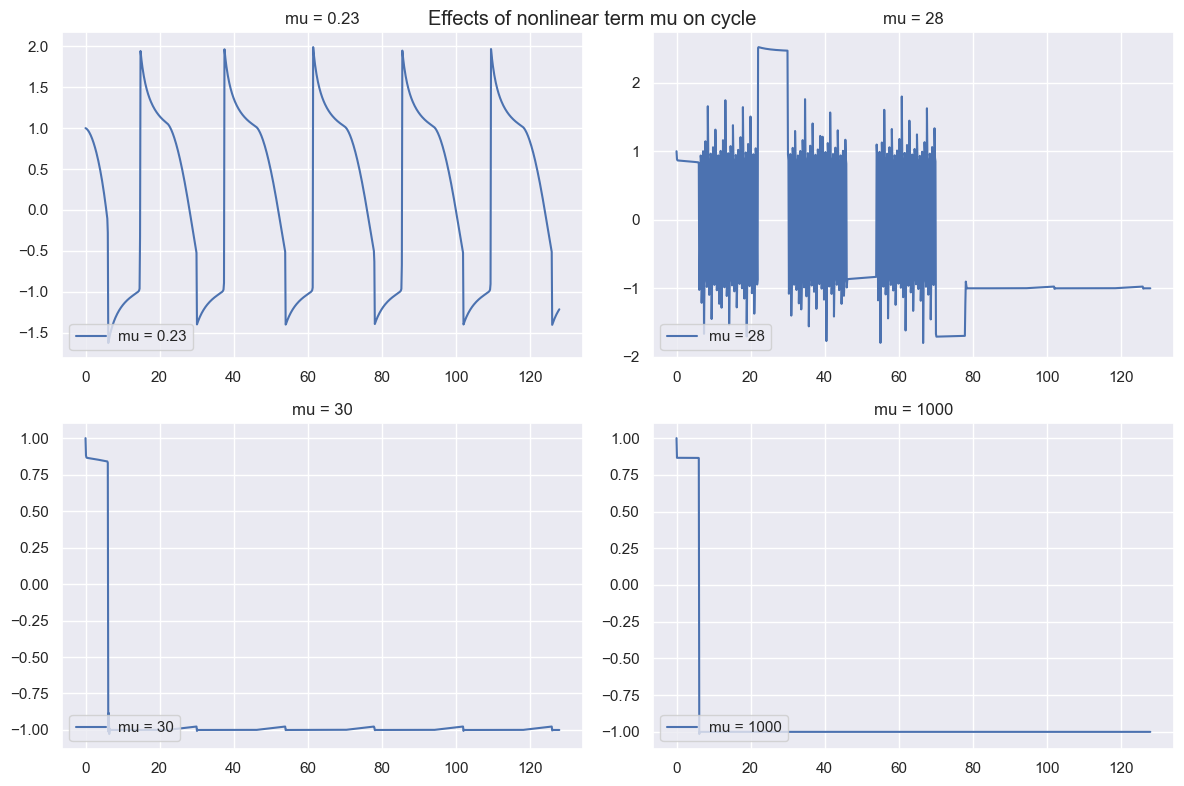

In [53]:
y0 = [0.0, 0.0, 1.0, 0.0]  # Start on limit cycle
dose_times = [0]
t_span = (0, 128)
t_eval = np.linspace(*t_span, 1000)
sol_m023 = solve_ivp(circadian_melatonin_model, t_span, y0,
                args=(dose_times,light_input,100.0,0.23,0.75,1.0,0.3,1.0,), t_eval=t_eval, method='Radau',atol=1e-10, rtol=1e-5)
sol_m28 = solve_ivp(circadian_melatonin_model, t_span, y0,
                args=(dose_times,light_input,100.0,28.0,0.75,1.0,0.3,1.0,), t_eval=t_eval, method='Radau',atol=1e-10, rtol=1e-5)
sol_m30 = solve_ivp(circadian_melatonin_model, t_span, y0,
                args=(dose_times,light_input,100.0,30.0,0.75,1.0,0.3,1.0,), t_eval=t_eval, method='Radau',atol=1e-10, rtol=1e-5)
sol_m1000 = solve_ivp(circadian_melatonin_model, t_span, y0,
                args=(dose_times,light_input,100.0,1000.0,0.75,1.0,0.3,1.0,), t_eval=t_eval, method='Radau',atol=1e-10, rtol=1e-5)
t = sol_m0.t
G, M, x0, y_osc = sol_m023.y 
G, M, x28, y_osc = sol_m28.y 
G, M, x30, y_osc = sol_m30.y 
G, M, x1000, y_osc = sol_m1000.y 
plt.figure(figsize=(12, 8))
plt.subplot(2, 2, 1)
plt.title("mu = 0.23")
plt.plot(t, x023, label='mu = 0.23')
plt.legend(loc='lower left')

plt.subplot(2, 2, 2)
plt.title("mu = 28")
plt.plot(t, x28, label='mu = 28')
plt.legend(loc='lower left')

plt.subplot(2, 2, 3)
plt.title("mu = 30")
plt.plot(t, x30, label='mu = 30')
plt.legend(loc='lower left')

plt.subplot(2, 2, 4)
plt.title("mu = 1000")
plt.plot(t, x1000, label='mu = 1000')
plt.legend(loc='lower left')
plt.tight_layout()

plt.suptitle('Effects of nonlinear term mu on cycle')